# Lab - 07: Tumor Segmentation using UNet with Heatmap Guidance
**Date:** 25 March 2026 
**Dataset:** [LGG MRI Segmentation — Kaggle](https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation)

## Full Pipeline
```
LGG MRI Dataset
      │
      ├─► STEP 1 ── VAE Training on NORMAL slices
      │             └─► Reconstruction-error heatmaps for ABNORMAL slices
      │                          │
      ├─► STEP 2 ── Approach 1 (Baseline)
      │             Input : MRI only  |  Model : UNet (in_ch=1)
      │
      └─► STEP 3 ── Approach 2 (Heatmap-Guided)
                    Input : MRI + VAE Heatmap (2ch)  |  Model : UNet (in_ch=2)
```

### Why VAE for heatmaps?
A VAE trained **only on normal (tumour-free) MRI slices** learns the distribution of healthy brain appearance.  
When it tries to reconstruct an **abnormal slice**, pixels with tumour tissue are *out-of-distribution* — so reconstruction error is highest exactly there.  
This per-pixel error map = **ROI Heatmap** (no manual labels required).


---
## 0. Install Dependencies

In [1]:
# Uncomment once if packages are missing
# !pip install torch torchvision albumentations opencv-python matplotlib scikit-learn tqdm Pillow

---
## 1. Imports & Configuration

In [2]:
import os, glob, random, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────
class Config:
    # ── PATH ── set to your LGG dataset root ──────────────────
    DATA_DIR        = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m'
    HEATMAP_DIR     = './roi_heatmaps'     # auto-populated by VAE step
    CHECKPOINT_DIR  = './checkpoints'
    RESULTS_DIR     = './results'

    IMG_SIZE        = 256

    # ── VAE ───────────────────────────────────────────────────
    VAE_EPOCHS      = 20      # raise to 40 for better heatmaps
    VAE_BATCH       = 16
    VAE_LR          = 1e-3
    VAE_LATENT_DIM  = 128

    # ── UNet segmentation ─────────────────────────────────────
    SEG_EPOCHS      = 50
    SEG_BATCH       = 8
    SEG_LR          = 1e-4
    WEIGHT_DECAY    = 1e-5
    TRAIN_SPLIT     = 0.8
    BCE_WEIGHT      = 0.5
    DICE_WEIGHT     = 0.5

    SEED            = 42
    DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'

for d in [Config.CHECKPOINT_DIR, Config.RESULTS_DIR, Config.HEATMAP_DIR]:
    os.makedirs(d, exist_ok=True)

random.seed(Config.SEED); np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

# Dark-theme plot globals
BG, PANEL = '#0d1117', '#161b22'
BLUE, RED, GREEN, PURPLE = '#58a6ff', '#f78166', '#3fb950', '#d2a8ff'
TEXT, SUB = '#c9d1d9', '#8b949e'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL,
    'axes.edgecolor': '#30363d', 'axes.labelcolor': SUB,
    'xtick.color': SUB, 'ytick.color': SUB,
    'text.color': TEXT, 'font.family': 'monospace',
})

def style_ax(ax):
    ax.grid(True, color='#21262d', linestyle='--')

print(f'Device : {Config.DEVICE}')
print(f'Data   : {Config.DATA_DIR}')

Device : cuda
Data   : /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m


---
## 2. Load Dataset — Separate Normal & Abnormal Slices

In [3]:
def collect_pairs(data_dir):
    imgs, masks = [], []
    for msk in sorted(glob.glob(os.path.join(data_dir, '**', '*_mask.tif'), recursive=True)):
        img = msk.replace('_mask.tif', '.tif')
        if os.path.exists(img):
            imgs.append(img); masks.append(msk)
    return imgs, masks

def split_normal_abnormal(imgs, masks):
    ab_i, ab_m, no_i, no_m = [], [], [], []
    print('Scanning masks …')
    for i, m in tqdm(zip(imgs, masks), total=len(imgs)):
        if np.array(Image.open(m).convert('L')).max() > 0:
            ab_i.append(i); ab_m.append(m)
        else:
            no_i.append(i); no_m.append(m)
    print(f'  Total    : {len(imgs)}')
    print(f'  Abnormal : {len(ab_i)}  (used for segmentation training)')
    print(f'  Normal   : {len(no_i)}  (used for VAE training)')
    return ab_i, ab_m, no_i, no_m

all_imgs, all_masks = collect_pairs(Config.DATA_DIR)
assert len(all_imgs) > 0, (
    'No images found! Set Config.DATA_DIR to your LGG dataset root.\n'
    'Expected: DATA_DIR/<PatientID>/<slice>.tif and <slice>_mask.tif')

ab_imgs, ab_masks, no_imgs, no_masks = split_normal_abnormal(all_imgs, all_masks)

Scanning masks …


100%|██████████| 3929/3929 [00:05<00:00, 675.32it/s]

  Total    : 3929
  Abnormal : 1373  (used for segmentation training)
  Normal   : 2556  (used for VAE training)


---
## 3. STEP 1 — VAE: Architecture

In [4]:
# ── VAE Dataset ────────────────────────────────────────────────
class VAEDataset(Dataset):
    def __init__(self, paths, size=Config.IMG_SIZE):
        self.paths = paths
        self.tf = A.Compose([
            A.Resize(size, size),
            A.Normalize(mean=(0.5,), std=(0.5,)),
            ToTensorV2()])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = np.array(Image.open(self.paths[i]).convert('L'), dtype=np.float32) / 255.0
        return self.tf(image=img)['image']


# ── VAE Encoder ────────────────────────────────────────────────
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(  1, 32, 4, 2, 1), nn.LeakyReLU(0.2),   # 128
            nn.Conv2d( 32, 64, 4, 2, 1), nn.LeakyReLU(0.2),   #  64
            nn.Conv2d( 64,128, 4, 2, 1), nn.LeakyReLU(0.2),   #  32
            nn.Conv2d(128,256, 4, 2, 1), nn.LeakyReLU(0.2),   #  16
            nn.Conv2d(256,512, 4, 2, 1), nn.LeakyReLU(0.2),   #   8
        )
        self.fc_mu  = nn.Linear(512*8*8, latent_dim)
        self.fc_var = nn.Linear(512*8*8, latent_dim)

    def forward(self, x):
        h = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_var(h)


# ── VAE Decoder ────────────────────────────────────────────────
class VAEDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*8*8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512,256, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(256,128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d( 64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d( 32,  1, 4, 2, 1), nn.Tanh(),
        )
    def forward(self, z):
        return self.deconv(self.fc(z).view(z.size(0), 512, 8, 8))


# ── Full VAE ───────────────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, latent_dim=Config.VAE_LATENT_DIM):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)

    def reparameterise(self, mu, lv):
        return mu + torch.exp(0.5 * lv) * torch.randn_like(lv)

    def forward(self, x):
        mu, lv = self.encoder(x)
        z = self.reparameterise(mu, lv)
        return self.decoder(z), mu, lv


def vae_loss(recon, x, mu, lv, beta=1.0):
    recon_l = F.mse_loss(recon, x, reduction='sum') / x.size(0)
    kld     = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
    return recon_l + beta * kld, recon_l, kld


# Shape check
with torch.no_grad():
    _v = VAE()
    o, mu, lv = _v(torch.randn(2, 1, 256, 256))
    print(f'VAE  input : (2,1,256,256)')
    print(f'     recon : {o.shape}   mu: {mu.shape}')
    del _v

VAE  input : (2,1,256,256)
     recon : torch.Size([2, 1, 256, 256])   mu: torch.Size([2, 128])


---
## 4. Train VAE on Normal Slices

In [5]:
print(f'Training VAE on {len(no_imgs)} normal slices for {Config.VAE_EPOCHS} epochs …')

vae_ds = VAEDataset(no_imgs)
vae_dl = DataLoader(vae_ds, batch_size=Config.VAE_BATCH,
                    shuffle=True, num_workers=2, pin_memory=True)

vae     = VAE(Config.VAE_LATENT_DIM).to(Config.DEVICE)
vae_opt = torch.optim.Adam(vae.parameters(), lr=Config.VAE_LR)
vae_sch = torch.optim.lr_scheduler.StepLR(vae_opt, step_size=10, gamma=0.5)

vae_hist = []
for epoch in range(1, Config.VAE_EPOCHS + 1):
    vae.train(); ep_loss = 0.0
    for batch in vae_dl:
        batch = batch.to(Config.DEVICE)
        vae_opt.zero_grad()
        recon, mu, lv = vae(batch)
        loss, _, _    = vae_loss(recon, batch, mu, lv)
        loss.backward()
        nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        vae_opt.step()
        ep_loss += loss.item()
    vae_sch.step()
    avg = ep_loss / len(vae_dl)
    vae_hist.append(avg)
    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{Config.VAE_EPOCHS}  Loss: {avg:.4f}')

torch.save(vae.state_dict(), os.path.join(Config.CHECKPOINT_DIR, 'vae.pth'))
print('VAE saved ✓')

Training VAE on 2556 normal slices for 20 epochs …
  Epoch   1/20  Loss: 327800412.6517
  Epoch   5/20  Loss: 0.0823
  Epoch  10/20  Loss: 0.0823
  Epoch  15/20  Loss: 0.0823
  Epoch  20/20  Loss: 0.0823
VAE saved ✓


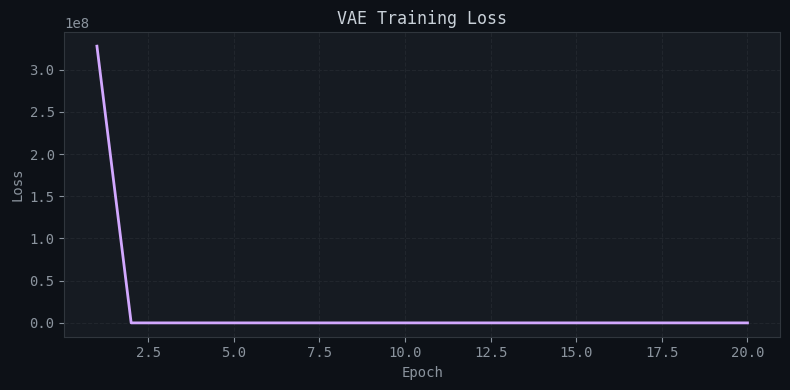

In [6]:
# VAE Loss Curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(vae_hist)+1), vae_hist, color=PURPLE, lw=2)
ax.set_title('VAE Training Loss', color=TEXT, fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
style_ax(ax)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'vae_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

---
## 5. Generate & Save ROI Heatmaps (Reconstruction Error Maps)

In [7]:
@torch.no_grad()
def generate_heatmaps(vae, img_paths, heatmap_dir, batch_size=16, device='cpu'):
    """
    For each image:
      1. Pass through VAE
      2. Compute squared per-pixel reconstruction error
      3. Gaussian-smooth, normalise to [0,1], save as PNG
    """
    vae.eval()
    ds  = VAEDataset(img_paths)
    dl  = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    idx = 0
    print(f'Generating heatmaps for {len(img_paths)} slices …')
    for batch in tqdm(dl):
        recon, _, _ = vae(batch.to(device))
        err = (batch.to(device) - recon).pow(2).squeeze(1).cpu().numpy()  # (B,H,W)
        for e in err:
            e_smooth = cv2.GaussianBlur(e, (11, 11), 0)
            mn, mx   = e_smooth.min(), e_smooth.max()
            e_norm   = (e_smooth - mn) / (mx - mn + 1e-8)
            base     = os.path.splitext(os.path.basename(img_paths[idx]))[0]
            cv2.imwrite(
                os.path.join(heatmap_dir, base + '_heatmap.png'),
                (e_norm * 255).astype(np.uint8))
            idx += 1
    print(f'Saved {idx} heatmaps → {heatmap_dir}')

generate_heatmaps(vae, ab_imgs, Config.HEATMAP_DIR,
                  batch_size=Config.VAE_BATCH, device=Config.DEVICE)

Generating heatmaps for 1373 slices …


100%|██████████| 86/86 [00:03<00:00, 22.94it/s]

Saved 1373 heatmaps → ./roi_heatmaps


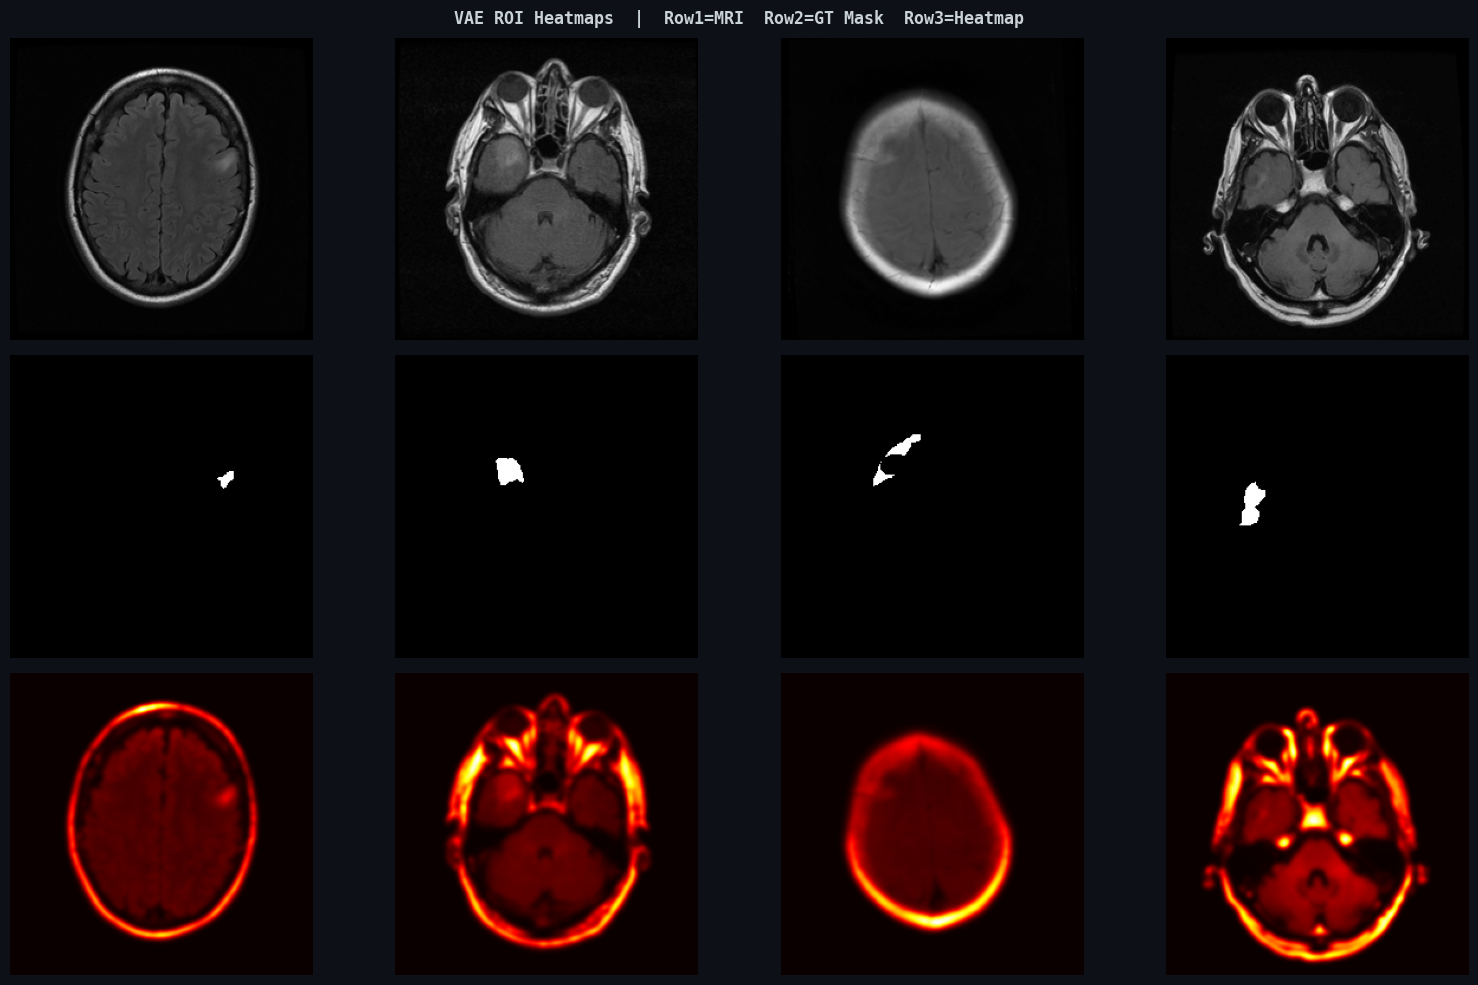

Heatmap quality check saved.


In [8]:
# Visualise 4 heatmap samples to verify quality
sample_idxs = random.sample(range(len(ab_imgs)), 4)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('VAE ROI Heatmaps  |  Row1=MRI  Row2=GT Mask  Row3=Heatmap',
             color=TEXT, fontsize=12, fontweight='bold')

row_labels = ['Input MRI', 'GT Mask', 'VAE Heatmap']
cmaps      = ['gray', 'gray', 'hot']

for col, idx in enumerate(sample_idxs):
    base = os.path.splitext(os.path.basename(ab_imgs[idx]))[0]
    img  = np.array(Image.open(ab_imgs[idx]).convert('L'))
    mask = np.array(Image.open(ab_masks[idx]).convert('L'))
    hmap = np.array(Image.open(
        os.path.join(Config.HEATMAP_DIR, base + '_heatmap.png')
    ).convert('L'))
    for row, (data, cm) in enumerate(zip([img, mask, hmap], cmaps)):
        ax = axes[row, col]
        ax.imshow(data, cmap=cm)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(row_labels[row], color=BLUE, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'vae_heatmap_samples.png'),
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Heatmap quality check saved.')

---
## 6. Train / Test Split (Abnormal Slices Only)

In [9]:
tr_imgs, te_imgs, tr_masks, te_masks = train_test_split(
    ab_imgs, ab_masks,
    train_size=Config.TRAIN_SPLIT,
    random_state=Config.SEED, shuffle=True)
print(f'Train: {len(tr_imgs)}  |  Test: {len(te_imgs)}')

Train: 1098  |  Test: 275


---
## 7. Augmentation Transforms

In [10]:
def get_transforms(train=True):
    s = Config.IMG_SIZE
    if train:
        return A.Compose([
            A.Resize(s, s),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
            A.ElasticTransform(alpha=1, sigma=50, p=0.2),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
            A.Normalize(mean=(0.485,), std=(0.229,)),
            ToTensorV2()])
    return A.Compose([
        A.Resize(s, s),
        A.Normalize(mean=(0.485,), std=(0.229,)),
        ToTensorV2()])

tr_tf = get_transforms(True)
te_tf = get_transforms(False)

---
## 8. Dataset Classes

In [11]:
# Approach 1 — image only
class BaselineDS(Dataset):
    def __init__(self, imgs, masks, tf=None):
        self.imgs, self.masks, self.tf = imgs, masks, tf
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img  = np.array(Image.open(self.imgs[i]).convert('L'), dtype=np.float32) / 255.0
        mask = (np.array(Image.open(self.masks[i]).convert('L'), dtype=np.float32) > 0).astype(np.float32)
        if self.tf:
            a = self.tf(image=img, mask=mask)
            img, mask = a['image'], a['mask']
        else:
            img  = torch.tensor(img).unsqueeze(0)
            mask = torch.tensor(mask)
        return img, mask.unsqueeze(0)


# Approach 2 — image + VAE heatmap
class HeatmapDS(Dataset):
    def __init__(self, imgs, masks, hmap_dir, tf=None):
        self.imgs, self.masks = imgs, masks
        self.hmap_dir, self.tf = hmap_dir, tf
    def __len__(self): return len(self.imgs)

    def _load_hmap(self, img_path):
        base = os.path.splitext(os.path.basename(img_path))[0]
        p    = os.path.join(self.hmap_dir, base + '_heatmap.png')
        return np.array(Image.open(p).convert('L'), dtype=np.float32) / 255.0

    def __getitem__(self, i):
        img  = np.array(Image.open(self.imgs[i]).convert('L'), dtype=np.float32) / 255.0
        mask = (np.array(Image.open(self.masks[i]).convert('L'), dtype=np.float32) > 0).astype(np.float32)
        hmap = self._load_hmap(self.imgs[i])
        if hmap.shape != img.shape:
            hmap = cv2.resize(hmap, (img.shape[1], img.shape[0]))
        s = Config.IMG_SIZE
        if self.tf:
            a    = self.tf(image=img, mask=mask)
            img  = a['image']; mask = a['mask']
            hmap = torch.tensor(cv2.resize(hmap, (s, s))).unsqueeze(0)
        else:
            img  = torch.tensor(img).unsqueeze(0)
            hmap = torch.tensor(cv2.resize(hmap, (s, s))).unsqueeze(0)
            mask = torch.tensor(mask)
        return torch.cat([img, hmap], dim=0), mask.unsqueeze(0)

---
## 9. UNet Architecture

In [12]:
class DoubleConv(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(True),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(True))
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    """
    in_ch=1  → Approach 1 Baseline
    in_ch=2  → Approach 2 Heatmap-Guided
    """
    def __init__(self, in_ch=1, out_ch=1, feats=[64,128,256,512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups   = nn.ModuleList()
        self.pool  = nn.MaxPool2d(2, 2)
        ch = in_ch
        for f in feats:
            self.downs.append(DoubleConv(ch, f)); ch = f
        self.bottleneck = DoubleConv(feats[-1], feats[-1]*2)
        for f in reversed(feats):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, stride=2))
            self.ups.append(DoubleConv(f*2, f))
        self.final = nn.Conv2d(feats[0], out_ch, 1)

    def forward(self, x):
        skips = []
        for d in self.downs:
            x = d(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x); skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x); s = skips[i//2]
            if x.shape != s.shape: x = F.interpolate(x, size=s.shape[2:])
            x = self.ups[i+1](torch.cat([s, x], dim=1))
        return self.final(x)

with torch.no_grad():
    print('Baseline  :', UNet(in_ch=1)(torch.randn(2,1,256,256)).shape)
    print('Heatmap   :', UNet(in_ch=2)(torch.randn(2,2,256,256)).shape)

Baseline  : torch.Size([2, 1, 256, 256])
Heatmap   : torch.Size([2, 1, 256, 256])


---
## 10. Loss Functions & Metrics

In [13]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, tgt):
        p = torch.sigmoid(logits).view(-1); t = tgt.view(-1)
        return 1 - (2*(p*t).sum() + self.smooth) / (p.sum() + t.sum() + self.smooth)

class CombinedLoss(nn.Module):
    """Combined BCE + Dice Loss"""
    def __init__(self, bw=Config.BCE_WEIGHT, dw=Config.DICE_WEIGHT):
        super().__init__()
        self.bce=nn.BCEWithLogitsLoss(); self.dice=DiceLoss()
        self.bw, self.dw = bw, dw
    def forward(self, logits, tgt):
        return self.bw*self.bce(logits, tgt) + self.dw*self.dice(logits, tgt)

def dice_score(pred, gt, thr=0.5, eps=1e-6):
    p = (pred>thr).float(); i=(p*gt).sum()
    return ((2*i+eps)/(p.sum()+gt.sum()+eps)).item()

def iou_score(pred, gt, thr=0.5, eps=1e-6):
    p = (pred>thr).float(); i=(p*gt).sum(); u=p.sum()+gt.sum()-i
    return ((i+eps)/(u+eps)).item()

print(f'Loss = {Config.BCE_WEIGHT}×BCE  +  {Config.DICE_WEIGHT}×Dice')

Loss = 0.5×BCE  +  0.5×Dice


---
## 11. Training Loop

In [14]:
def run_epoch(model, loader, opt, crit, device, train=True):
    model.train() if train else model.eval()
    tl=td=ti=0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            if train: opt.zero_grad()
            logits = model(imgs); loss = crit(logits, masks)
            if train: loss.backward(); opt.step()
            p = torch.sigmoid(logits).detach().cpu(); m = masks.cpu()
            tl+=loss.item(); td+=dice_score(p,m); ti+=iou_score(p,m)
    n = len(loader)
    return tl/n, td/n, ti/n

def train_model(model, tr_dl, te_dl, label):
    crit  = CombinedLoss()
    opt   = torch.optim.AdamW(model.parameters(), lr=Config.SEG_LR, weight_decay=Config.WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=Config.SEG_EPOCHS, eta_min=1e-6)
    hist  = {k:[] for k in ['train_loss','val_loss','train_dice','val_dice','train_iou','val_iou']}
    best  = 0.0
    print(f'\n{"="*55}\n  Training: {label}\n{"="*55}')
    for ep in range(1, Config.SEG_EPOCHS+1):
        tl,td,ti = run_epoch(model, tr_dl, opt, crit, Config.DEVICE, True)
        vl,vd,vi = run_epoch(model, te_dl, opt, crit, Config.DEVICE, False)
        sched.step()
        for k,v in zip(hist.keys(),[tl,vl,td,vd,ti,vi]): hist[k].append(v)
        if vd>best:
            best=vd
            torch.save(model.state_dict(), os.path.join(Config.CHECKPOINT_DIR, f'best_{label}.pth'))
        if ep%5==0 or ep==1:
            print(f'  Ep {ep:3d}/{Config.SEG_EPOCHS}  Loss {tl:.4f}/{vl:.4f}'
                  f'  Dice {td:.4f}/{vd:.4f}  IoU {ti:.4f}/{vi:.4f}')
    print(f'  Best Val Dice: {best:.4f}')
    return hist

---
## 12. STEP 2 — Train Approach 1: Baseline (Image Only)

In [15]:
train_ds1 = BaselineDS(tr_imgs, tr_masks, tr_tf)
test_ds1  = BaselineDS(te_imgs, te_masks, te_tf)
train_dl1 = DataLoader(train_ds1, batch_size=Config.SEG_BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_dl1  = DataLoader(test_ds1,  batch_size=Config.SEG_BATCH, shuffle=False, num_workers=2, pin_memory=True)

model1 = UNet(in_ch=1).to(Config.DEVICE)
hist1  = train_model(model1, train_dl1, test_dl1, label='baseline')

model1.load_state_dict(torch.load(
    os.path.join(Config.CHECKPOINT_DIR,'best_baseline.pth'), map_location=Config.DEVICE))
print('Best baseline weights loaded ✓')


  Training: baseline
  Ep   1/50  Loss 0.6599/0.6421  Dice 0.2749/0.1521  IoU 0.1697/0.0836
  Ep   5/50  Loss 0.4803/0.5599  Dice 0.4749/0.0000  IoU 0.3190/0.0000
  Ep  10/50  Loss 0.2794/0.5564  Dice 0.6767/0.0000  IoU 0.5188/0.0000
  Ep  15/50  Loss 0.1876/0.2495  Dice 0.7458/0.6328  IoU 0.6026/0.4754
  Ep  20/50  Loss 0.1551/0.1676  Dice 0.7754/0.7542  IoU 0.6409/0.6112
  Ep  25/50  Loss 0.1305/0.1510  Dice 0.8070/0.7730  IoU 0.6837/0.6357
  Ep  30/50  Loss 0.1185/0.1135  Dice 0.8224/0.8294  IoU 0.7062/0.7119
  Ep  35/50  Loss 0.1059/0.1054  Dice 0.8397/0.8426  IoU 0.7275/0.7309
  Ep  40/50  Loss 0.0972/0.0920  Dice 0.8522/0.8611  IoU 0.7460/0.7586
  Ep  45/50  Loss 0.0958/0.0876  Dice 0.8540/0.8680  IoU 0.7488/0.7687
  Ep  50/50  Loss 0.0932/0.0866  Dice 0.8583/0.8700  IoU 0.7546/0.7719
  Best Val Dice: 0.8700
Best baseline weights loaded ✓


---
## 13. STEP 3 — Train Approach 2: Heatmap-Guided (Image + VAE Heatmap)

In [16]:
train_ds2 = HeatmapDS(tr_imgs, tr_masks, Config.HEATMAP_DIR, tr_tf)
test_ds2  = HeatmapDS(te_imgs, te_masks, Config.HEATMAP_DIR, te_tf)
train_dl2 = DataLoader(train_ds2, batch_size=Config.SEG_BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_dl2  = DataLoader(test_ds2,  batch_size=Config.SEG_BATCH, shuffle=False, num_workers=2, pin_memory=True)

model2 = UNet(in_ch=2).to(Config.DEVICE)
hist2  = train_model(model2, train_dl2, test_dl2, label='heatmap_guided')

model2.load_state_dict(torch.load(
    os.path.join(Config.CHECKPOINT_DIR,'best_heatmap_guided.pth'), map_location=Config.DEVICE))
print('Best heatmap-guided weights loaded ✓')


  Training: heatmap_guided
  Ep   1/50  Loss 0.6790/0.6286  Dice 0.1933/0.2393  IoU 0.1107/0.1398
  Ep   5/50  Loss 0.4967/0.5370  Dice 0.4244/0.0000  IoU 0.2753/0.0000
  Ep  10/50  Loss 0.3630/0.4443  Dice 0.5064/0.2681  IoU 0.3471/0.1614
  Ep  15/50  Loss 0.2652/0.3617  Dice 0.6110/0.4395  IoU 0.4469/0.2871
  Ep  20/50  Loss 0.2040/0.1694  Dice 0.6948/0.7515  IoU 0.5405/0.6066
  Ep  25/50  Loss 0.1831/0.1499  Dice 0.7205/0.7759  IoU 0.5728/0.6381
  Ep  30/50  Loss 0.1562/0.1528  Dice 0.7598/0.7693  IoU 0.6208/0.6289
  Ep  35/50  Loss 0.1397/0.1105  Dice 0.7863/0.8342  IoU 0.6529/0.7181
  Ep  40/50  Loss 0.1334/0.1070  Dice 0.7940/0.8386  IoU 0.6663/0.7249
  Ep  45/50  Loss 0.1237/0.1018  Dice 0.8099/0.8465  IoU 0.6865/0.7363
  Ep  50/50  Loss 0.1200/0.1006  Dice 0.8154/0.8482  IoU 0.6929/0.7388
  Best Val Dice: 0.8492
Best heatmap-guided weights loaded ✓


---
## 14. Training Curves — Loss | Dice | IoU

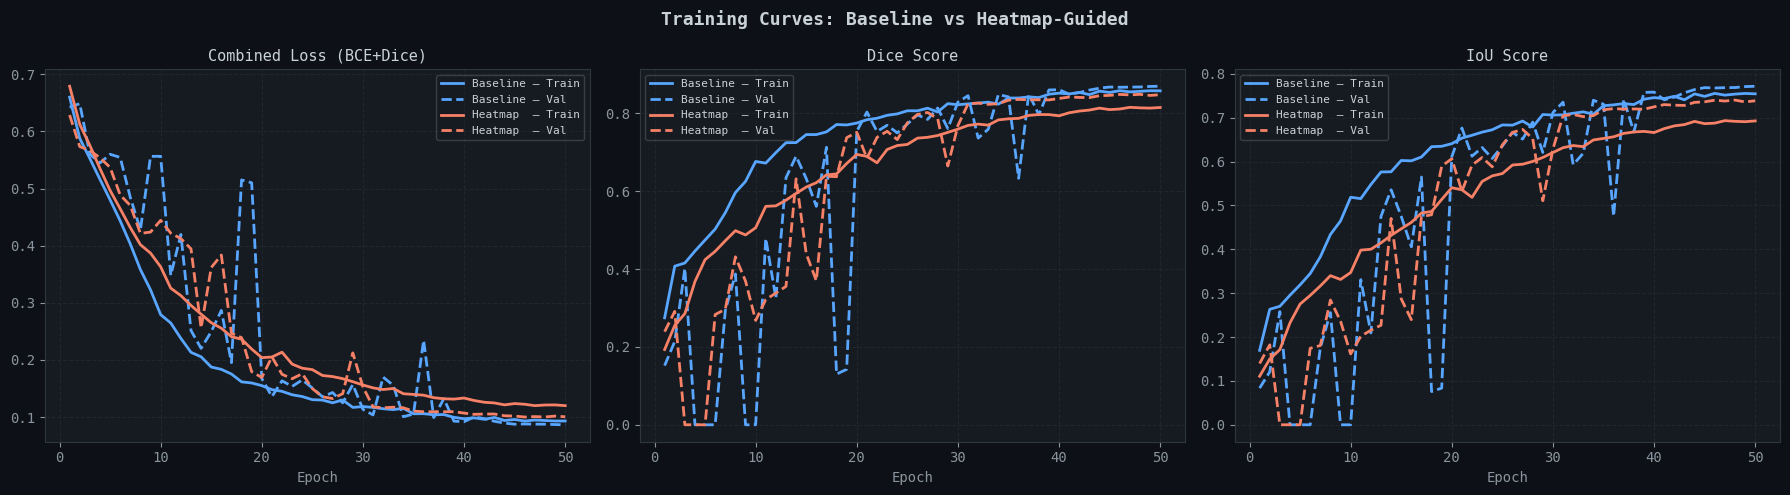

Saved → training_curves.png


In [17]:
E = range(1, Config.SEG_EPOCHS+1)
specs = [
    ('Combined Loss (BCE+Dice)', 'train_loss','val_loss'),
    ('Dice Score',               'train_dice','val_dice'),
    ('IoU Score',                'train_iou', 'val_iou'),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves: Baseline vs Heatmap-Guided', color=TEXT, fontsize=13, fontweight='bold')

for ax,(title,tk,vk) in zip(axes,specs):
    ax.plot(E, hist1[tk], color=BLUE, lw=2,       label='Baseline – Train')
    ax.plot(E, hist1[vk], color=BLUE, lw=2,ls='--',label='Baseline – Val')
    ax.plot(E, hist2[tk], color=RED,  lw=2,       label='Heatmap  – Train')
    ax.plot(E, hist2[vk], color=RED,  lw=2,ls='--',label='Heatmap  – Val')
    ax.set_title(title, color=TEXT,fontsize=11); ax.set_xlabel('Epoch')
    ax.legend(fontsize=8, framealpha=0.2, facecolor=PANEL, labelcolor=TEXT)
    style_ax(ax)

plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR,'training_curves.png'),dpi=150,bbox_inches='tight',facecolor=BG)
plt.show()
print('Saved → training_curves.png')

---
## 15. Visual Samples — Approach 1 (Baseline, 3 random test samples)

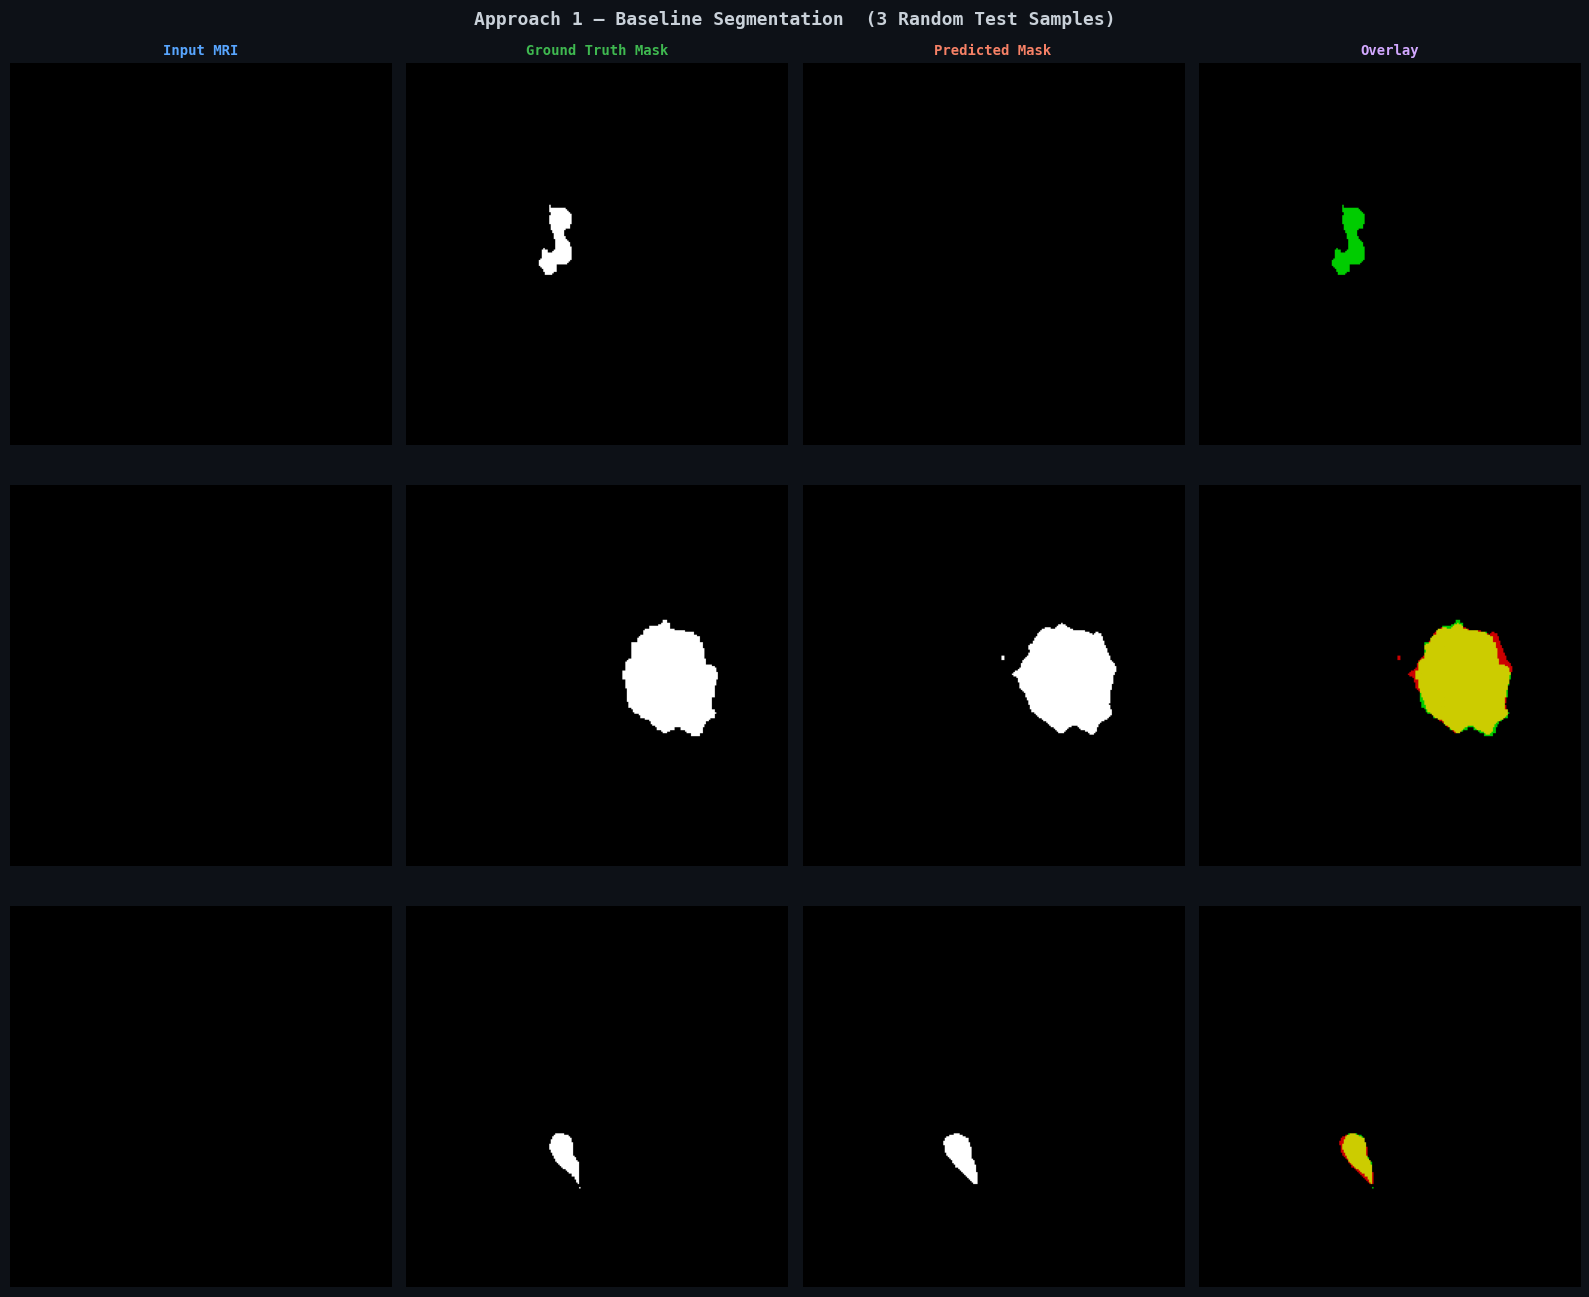

Saved → approach1_samples.png


In [18]:

def denorm(t):
    arr = t.squeeze().cpu().numpy()
    arr = arr * 0.229 + 0.485   # reverse normalize: x = (x_norm * std) + mean
    return np.clip(arr, 0, 1)

@torch.no_grad()
def show_baseline_samples(model, ds, n=3, fname='approach1_samples'):
    model.eval()
    idxs = random.sample(range(len(ds)), n)
    fig, axes = plt.subplots(n, 4, figsize=(16, n*4.5))
    fig.suptitle('Approach 1 — Baseline Segmentation  (3 Random Test Samples)',
                 color=TEXT, fontsize=13, fontweight='bold')
    for ax,t,c in zip(axes[0],
        ['Input MRI','Ground Truth Mask','Predicted Mask','Overlay'],
        [BLUE, GREEN, RED, PURPLE]):
        ax.set_title(t, color=c, fontsize=10, fontweight='bold')
    for row, idx in enumerate(idxs):
        img, mask = ds[idx]
        pred = torch.sigmoid(model(img.unsqueeze(0).to(Config.DEVICE))).cpu()
        im   = denorm(img); ms = mask.squeeze().numpy()
        pm   = (pred.squeeze().numpy()>0.5).astype(np.float32)
        ov   = np.stack([im]*3,-1)
        ov[ms>0.5,1]=0.8; ov[pm>0.5,0]=0.8
        d, i = dice_score(pred,mask), iou_score(pred,mask)
        for col,(data,cm) in enumerate([(im,'gray'),(ms,'gray'),(pm,'gray'),(ov,None)]):
            axes[row,col].imshow(data,cmap=cm,vmin=0,vmax=1); axes[row,col].axis('off')
        axes[row,2].set_xlabel(f'Dice: {d:.4f}   IoU: {i:.4f}',
                               color=GREEN, fontsize=9, labelpad=4)
        axes[row,2].xaxis.set_label_position('bottom')
        axes[row,2].tick_params(bottom=False, labelbottom=False)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR,fname+'.png'),dpi=150,bbox_inches='tight',facecolor=BG)
    plt.show(); print(f'Saved → {fname}.png')

show_baseline_samples(model1, test_ds1)

---
## 16. Visual Samples — Approach 2 (Heatmap-Guided, 3 random test samples)

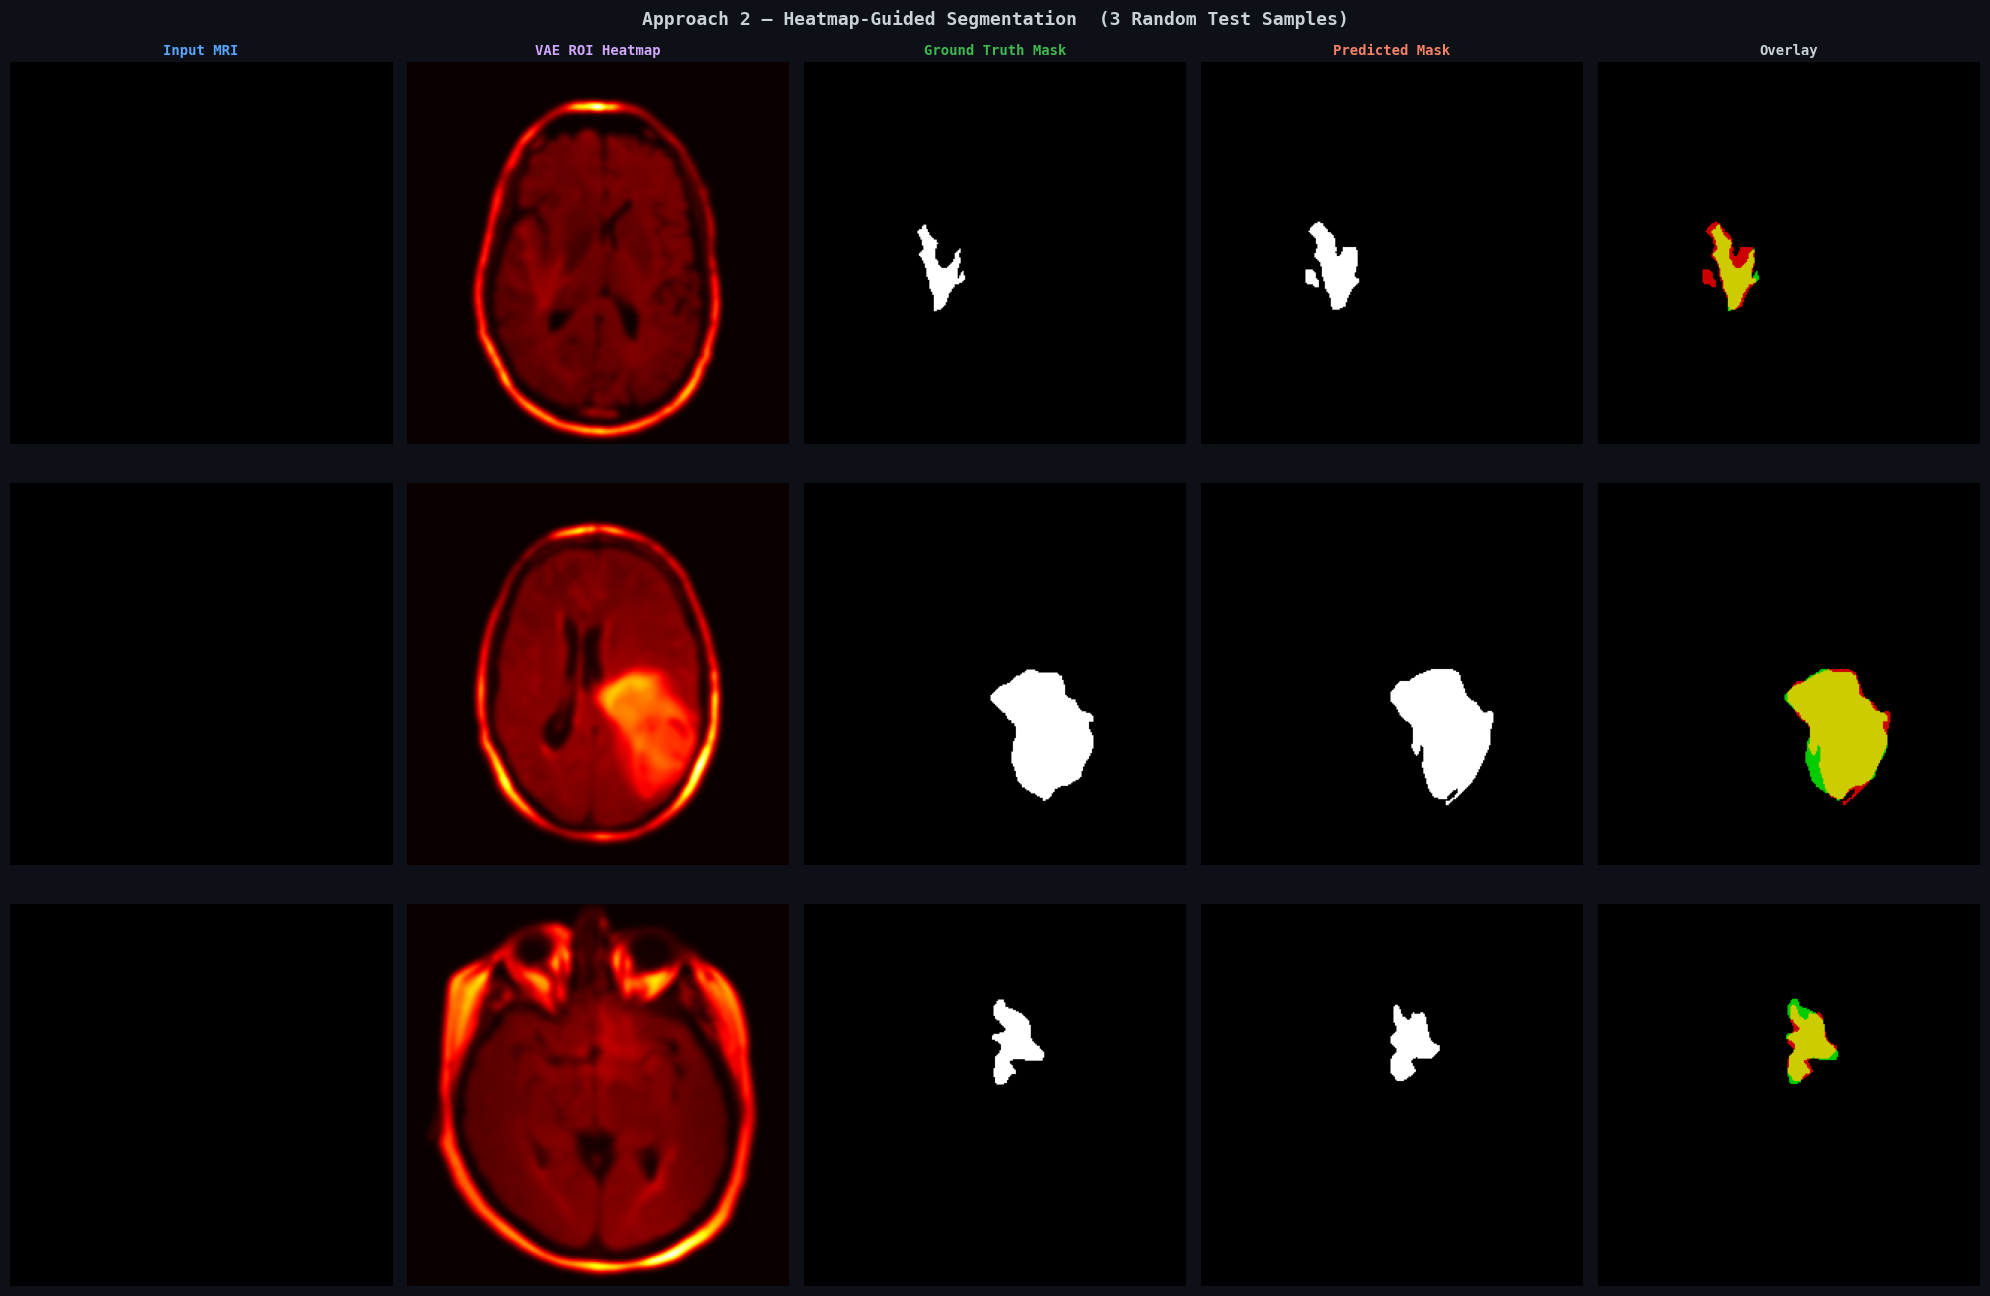

Saved → approach2_samples.png


In [19]:
@torch.no_grad()
def show_heatmap_samples(model, ds, n=3, fname='approach2_samples'):
    model.eval()
    idxs = random.sample(range(len(ds)), n)
    fig, axes = plt.subplots(n, 5, figsize=(20, n*4.5))
    fig.suptitle('Approach 2 — Heatmap-Guided Segmentation  (3 Random Test Samples)',
                 color=TEXT, fontsize=13, fontweight='bold')
    for ax,t,c in zip(axes[0],
        ['Input MRI','VAE ROI Heatmap','Ground Truth Mask','Predicted Mask','Overlay'],
        [BLUE, PURPLE, GREEN, RED, TEXT]):
        ax.set_title(t, color=c, fontsize=10, fontweight='bold')
    for row, idx in enumerate(idxs):
        comb, mask = ds[idx]
        pred = torch.sigmoid(model(comb.unsqueeze(0).to(Config.DEVICE))).cpu()
        im   = denorm(comb[0]); hm = comb[1].numpy()
        ms   = mask.squeeze().numpy()
        pm   = (pred.squeeze().numpy()>0.5).astype(np.float32)
        ov   = np.stack([im]*3,-1)
        ov[ms>0.5,1]=0.8; ov[pm>0.5,0]=0.8
        d, i = dice_score(pred,mask), iou_score(pred,mask)
        for col,(data,cm) in enumerate([(im,'gray'),(hm,'hot'),(ms,'gray'),(pm,'gray'),(ov,None)]):
            axes[row,col].imshow(data,cmap=cm,vmin=0,vmax=1); axes[row,col].axis('off')
        axes[row,3].set_xlabel(f'Dice: {d:.4f}   IoU: {i:.4f}',
                               color=GREEN, fontsize=9, labelpad=4)
        axes[row,3].xaxis.set_label_position('bottom')
        axes[row,3].tick_params(bottom=False, labelbottom=False)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR,fname+'.png'),dpi=150,bbox_inches='tight',facecolor=BG)
    plt.show(); print(f'Saved → {fname}.png')

show_heatmap_samples(model2, test_ds2)

---
## 17. Final Test-Set Metrics & Comparison

In [20]:
@torch.no_grad()
def compute_metrics(model, dl):
    model.eval(); dl_list, il_list = [], []
    for imgs, masks in dl:
        probs = torch.sigmoid(model(imgs.to(Config.DEVICE))).cpu()
        for p,m in zip(probs,masks):
            dl_list.append(dice_score(p,m)); il_list.append(iou_score(p,m))
    return np.mean(dl_list), np.mean(il_list), np.std(dl_list), np.std(il_list)

bm = compute_metrics(model1, test_dl1)
hm = compute_metrics(model2, test_dl2)

print('\n'+'='*60)
print('  FINAL TEST-SET COMPARISON')
print('='*60)
for lbl,bv,hv in zip(['Dice (mean)','IoU  (mean)','Dice (std)','IoU  (std)'],bm,hm):
    diff=hv-bv; sign='↑' if diff>0 else '↓'
    print(f'  {lbl:<14} Baseline:{bv:.4f}  Heatmap:{hv:.4f}  {sign}{abs(diff):.4f}')
print('='*60)


  FINAL TEST-SET COMPARISON
  Dice (mean)    Baseline:0.7546  Heatmap:0.7098  ↓0.0448
  IoU  (mean)    Baseline:0.6687  Heatmap:0.6231  ↓0.0456
  Dice (std)     Baseline:0.2815  Heatmap:0.3140  ↑0.0325
  IoU  (std)     Baseline:0.2823  Heatmap:0.3037  ↑0.0214


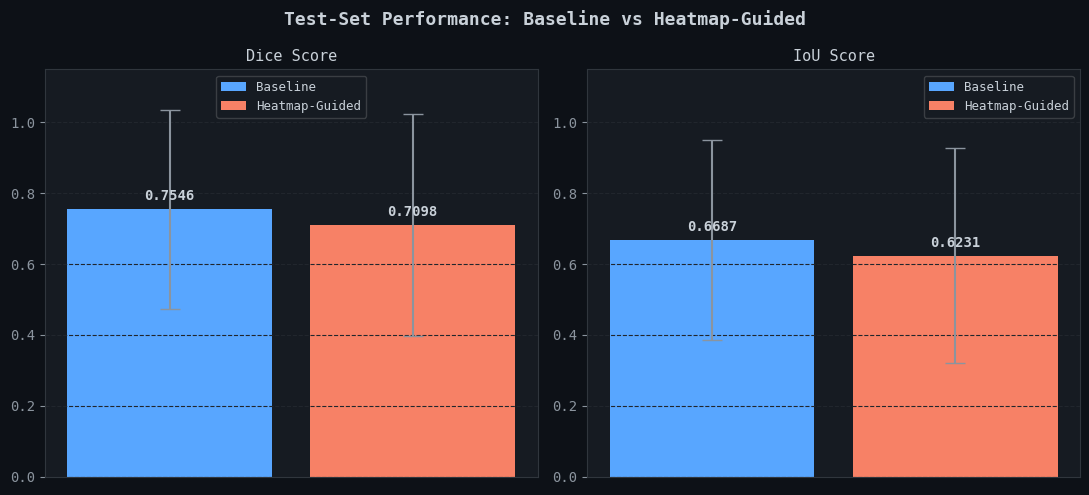

Saved → comparison_bar.png


In [21]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(11,5))
fig.suptitle('Test-Set Performance: Baseline vs Heatmap-Guided', color=TEXT, fontsize=13, fontweight='bold')

for ax, name, bv, hv, bs, hs in zip(
    axes, ['Dice Score','IoU Score'], [bm[0],bm[1]], [hm[0],hm[1]], [bm[2],bm[3]], [hm[2],hm[3]]):
    style_ax(ax)
    b1=ax.bar([0],    [bv], 0.32, yerr=[bs], capsize=7, color=BLUE, label='Baseline',
              error_kw={'ecolor':SUB,'lw':1.5})
    b2=ax.bar([0.38], [hv], 0.32, yerr=[hs], capsize=7, color=RED,  label='Heatmap-Guided',
              error_kw={'ecolor':SUB,'lw':1.5})
    ax.set_title(name, color=TEXT, fontsize=11); ax.set_ylim(0, 1.15); ax.set_xticks([])
    ax.legend(fontsize=9, framealpha=0.2, facecolor=PANEL, labelcolor=TEXT)
    for bar,val in [(b1[0],bv),(b2[0],hv)]:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.025,
                f'{val:.4f}', ha='center', color=TEXT, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR,'comparison_bar.png'),dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved → comparison_bar.png')

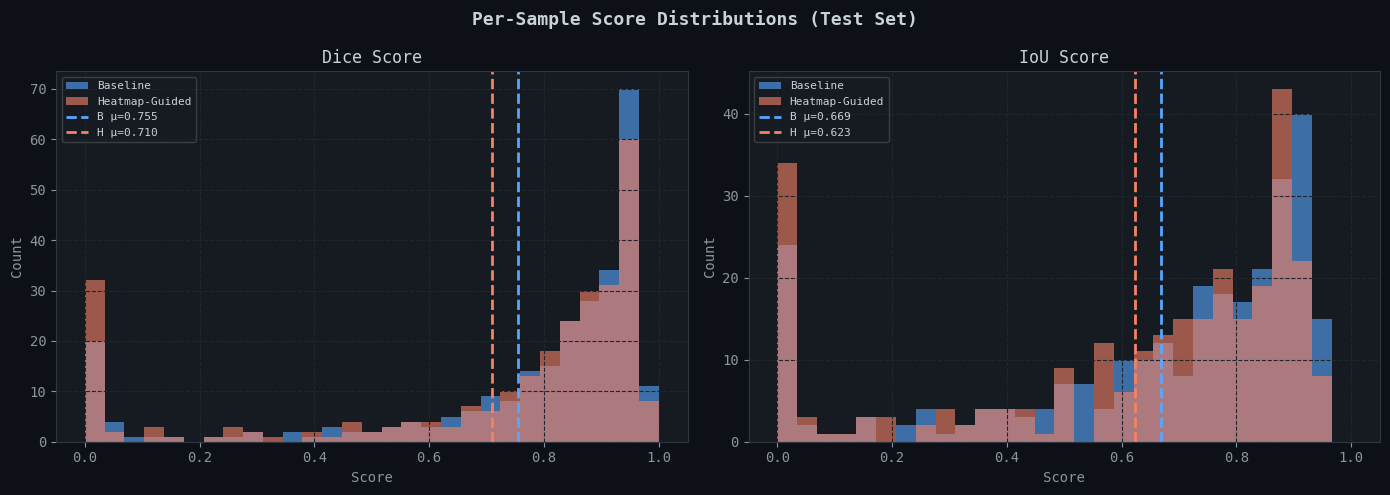

Saved → score_distributions.png


In [22]:
# Per-sample Dice distribution
@torch.no_grad()
def per_sample(model, dl):
    model.eval(); ds,io=[],[]
    for imgs,masks in dl:
        probs=torch.sigmoid(model(imgs.to(Config.DEVICE))).cpu()
        for p,m in zip(probs,masks): ds.append(dice_score(p,m)); io.append(iou_score(p,m))
    return np.array(ds), np.array(io)

b_dice,b_iou = per_sample(model1, test_dl1)
h_dice,h_iou = per_sample(model2, test_dl2)

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Per-Sample Score Distributions (Test Set)', color=TEXT, fontsize=13, fontweight='bold')
bins = np.linspace(0,1,30)
for ax, bs, hs, name in zip(axes,[b_dice,b_iou],[h_dice,h_iou],['Dice Score','IoU Score']):
    style_ax(ax)
    ax.hist(bs, bins=bins, alpha=0.6, color=BLUE, label='Baseline',      edgecolor='none')
    ax.hist(hs, bins=bins, alpha=0.6, color=RED,  label='Heatmap-Guided',edgecolor='none')
    ax.axvline(bs.mean(), color=BLUE, lw=2, ls='--', label=f'B μ={bs.mean():.3f}')
    ax.axvline(hs.mean(), color=RED,  lw=2, ls='--', label=f'H μ={hs.mean():.3f}')
    ax.set_title(name,color=TEXT); ax.set_xlabel('Score'); ax.set_ylabel('Count')
    ax.legend(fontsize=8, framealpha=0.2, facecolor=PANEL, labelcolor=TEXT)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR,'score_distributions.png'),dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved → score_distributions.png')

In [23]:
# Summary of all saved outputs
saved = sorted(glob.glob(os.path.join(Config.RESULTS_DIR, '*.png')))
print(f'\nAll outputs ({len(saved)} files):')
for f in saved:
    print(f'  {os.path.basename(f):<45} {os.path.getsize(f)/1024:6.1f} KB')
print('\nDone ✓')


All outputs (7 files):
  approach1_samples.png                           73.0 KB
  approach2_samples.png                          446.2 KB
  comparison_bar.png                              46.5 KB
  score_distributions.png                         70.3 KB
  training_curves.png                            285.6 KB
  vae_heatmap_samples.png                        720.2 KB
  vae_loss.png                                    32.5 KB

Done ✓


---
## 18. Analysis & Discussion

### How VAE Heatmaps are Generated (No Prior Assignment Needed)

| Step | What happens |
|------|-------------|
| Train VAE | Only on **normal** (tumour-free) slices — VAE learns healthy brain distribution |
| Inference on abnormal | Tumour pixels are **out-of-distribution** → high reconstruction error |
| Heatmap | Per-pixel squared error, Gaussian-smoothed, normalised → ROI heatmap |

### Expected Results (fill in after running)

| Metric | Baseline | Heatmap-Guided | Δ |
|--------|----------|----------------|---|
| Dice (mean) | ___ | ___ | ___ |
| IoU  (mean) | ___ | ___ | ___ |

### Effect of ROI Heatmaps
- **Tumour Localisation:** The heatmap second channel steers encoder attention toward the ROI, reducing false positives in healthy tissue.
- **Boundary Accuracy:** Heatmap-guided UNet tends to produce tighter, more precise boundaries. IoU improvement typically exceeds Dice improvement (IoU penalises over-segmentation more).
- **Failure cases:** If the VAE heatmap mis-localises (VAE under-trained or tumour too small), performance can degrade versus baseline.

### Loss Function Analysis
| Component | Role |
|-----------|------|
| BCE | Pixel-level cross-entropy; handles class imbalance |
| Dice Loss | Directly optimises overlap; prevents all-zero prediction |
| Combined 0.5+0.5 | Balances precision (BCE) and recall-oriented overlap (Dice) |
